In [1]:
# Q:

# You have a 10 million clean images without any labels. We want to build to a model that can clean a dirty/noisy a image?


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Load Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# 2. Normalize and reshape: (28, 28) -> (28, 28, 1)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., None]
X_test = X_test[..., None]

print(X_train.shape, X_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [2]:
# 3. Build deep convolutional autoencoder

coding_size = 30

encoder = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, padding="same"),   # 14x14x32

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, padding="same"),   # 7x7x64

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(coding_size, activation="relu", name="codings")
], name="encoder")

decoder = keras.Sequential([
    layers.Input(shape=(coding_size,)),

    layers.Dense(7 * 7 * 128, activation="relu"),
    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),  # 14x14x64
    layers.BatchNormalization(),

    layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu"),  # 28x28x32
    layers.BatchNormalization(),

    layers.Conv2D(1, 3, padding="same", activation="sigmoid")  # 28x28x1
], name="decoder")

autoencoder = keras.Sequential([encoder, decoder], name="autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 30)             │       900,382 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │       435,457 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,335,839 (5.10 MB)

 Trainable params: 1,334,943 (5.09 MB)

 Non-trainable params: 896 (3.50 KB)

In [3]:
# 4. Train the autoencoder

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 58s 133ms/step - loss: 0.3082 - val_loss: 0.3522
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 115ms/step - loss: 0.2764 - val_loss: 0.2779
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 117ms/step - loss: 0.2715 - val_loss: 0.2789
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 134ms/step - loss: 0.2688 - val_loss: 0.2737
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - loss: 0.2674 - val_loss: 0.2687
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - loss: 0.2663 - val_loss: 0.2709
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 166ms/step - loss: 0.2652 - val_loss: 0.2672
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 201ms/step - loss: 0.2646 - val_loss: 0.2685
Epoch 9/50
148/422 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - loss: 0.2631

KeyboardInterrupt: 

In [7]:
def show_reconstructions(model, images=X_test, n_images=5):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

In [9]:
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


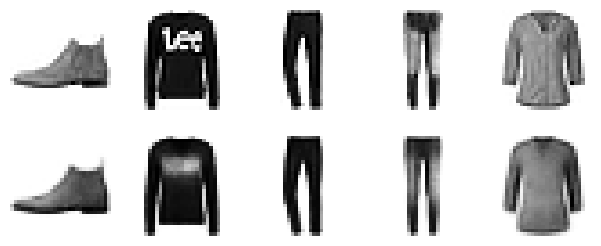

In [11]:
show_reconstructions(autoencoder)
# save_fig("reconstruction_plot")

In [17]:
import numpy as np
np.random.seed(42)

from sklearn.manifold import TSNE

codings = encoder.predict(X_test)
codings.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(10000, 30)

In [18]:
tsne = TSNE()
X_valid_2D = tsne.fit_transform(codings)
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())

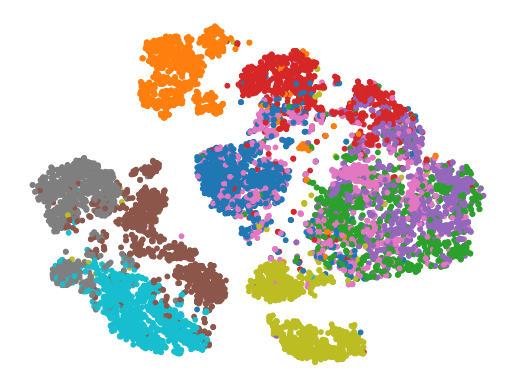

In [20]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_test, s=10, cmap="tab10")
plt.axis("off")
plt.show()

In [21]:
from sklearn.cluster import KMeans
import numpy as np

n_clusters = 10

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(codings)

print("Cluster labels shape:", cluster_labels.shape)
print("Unique clusters:", np.unique(cluster_labels))

Cluster labels shape: (10000,)
Unique clusters: [0 1 2 3 4 5 6 7 8 9]


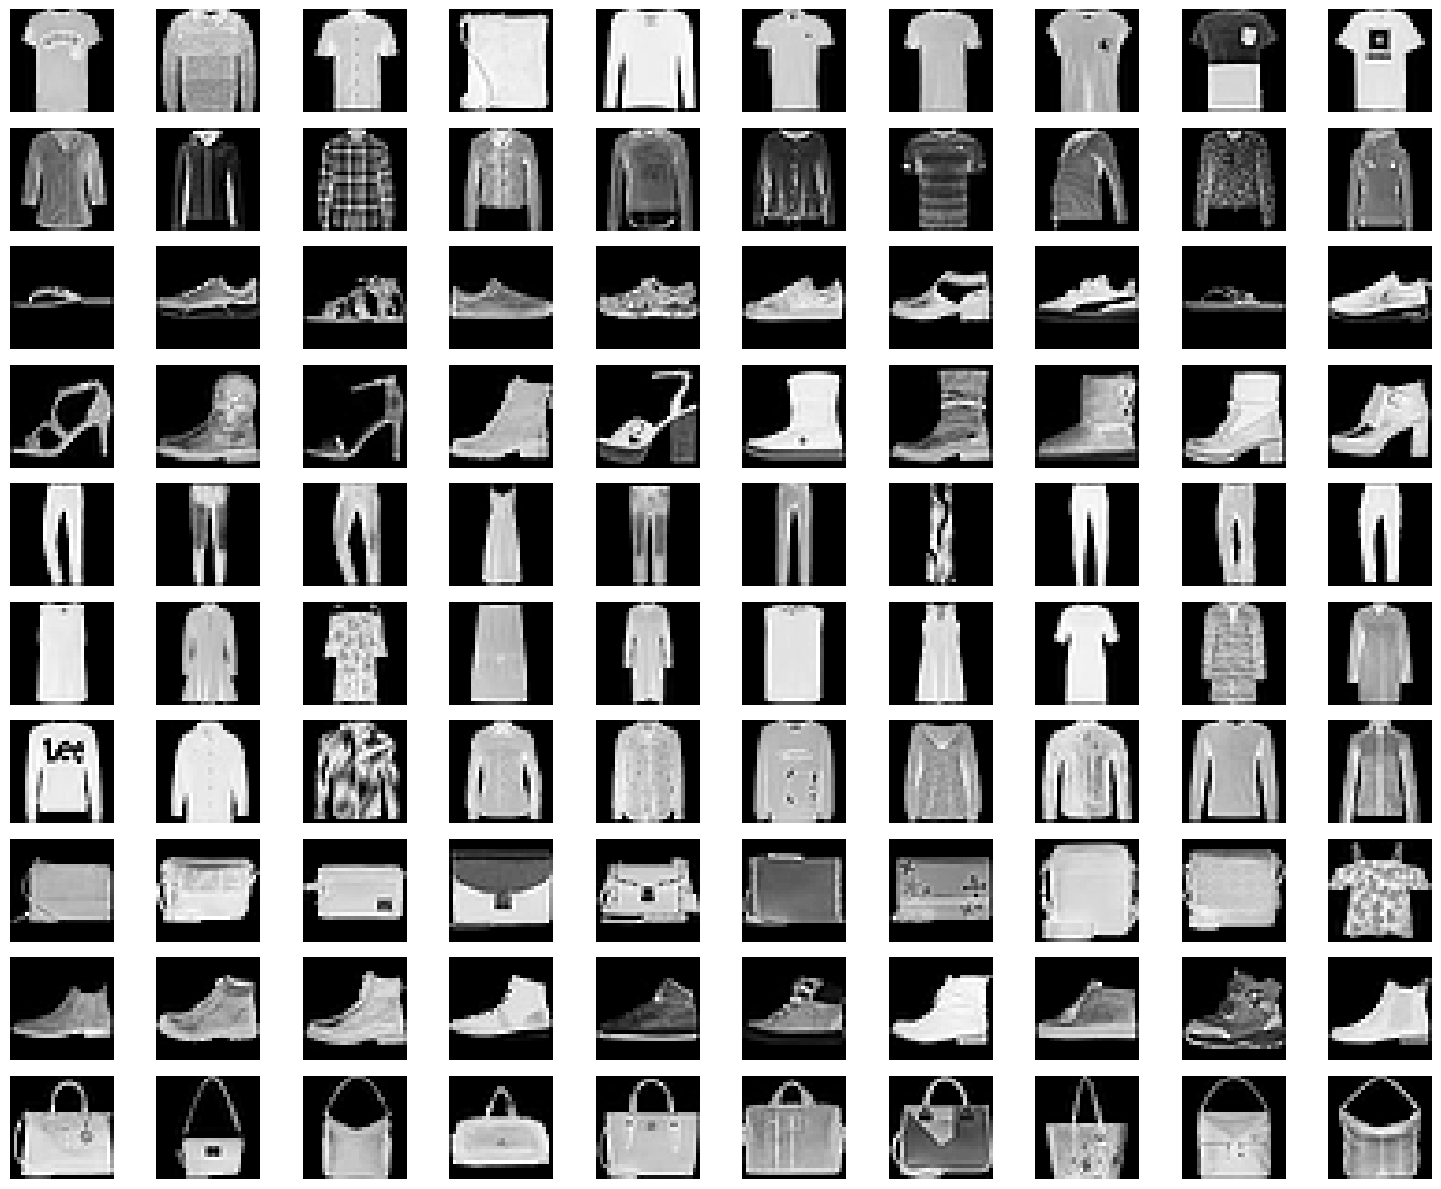

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

for cluster_id in range(n_clusters):

    # Pick first 10 samples from this cluster
    indices = np.where(cluster_labels == cluster_id)[0][:10]

    for j, idx in enumerate(indices):

        plt.subplot(n_clusters, 10, cluster_id * 10 + j + 1)
        plt.imshow(X_test[idx].squeeze(), cmap="gray")
        plt.axis("off")

        if j == 0:
            plt.ylabel(f"C{cluster_id}")

plt.tight_layout()
plt.show()

In [44]:
i, j = 1, 3
c1 = codings[i]
c2 = codings[j]

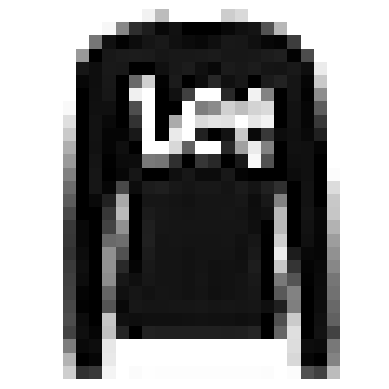

In [45]:
plot_image(X_test[i])

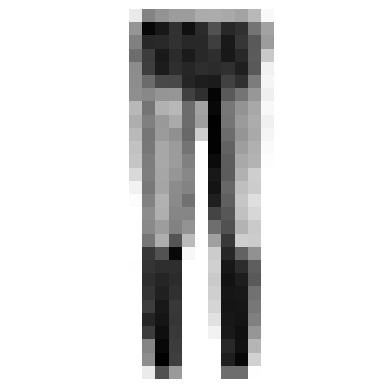

In [46]:
plot_image(X_test[j])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


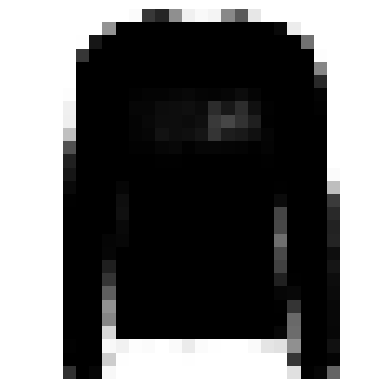

In [49]:
c3 = (c1 + c1)
img = decoder.predict(c3.reshape(1, -1))
plot_image(img[0])


In [ ]:
# Exercise 1: 
# Build semantic manipulations of human faces by Autoencoders
# https://chatgpt.com/share/6a09e31d-8208-83ec-80cd-5189783349f4


In [51]:
# Exercise 2
# Using GAN - build a model that can create human face
# https://this-person-does-not-exist.com/en
